# Sinhala Buddhist Corpus - Analysis and Preprocessing

This notebook performs:
1. **Pre-processing Analysis** - Statistics on raw extracted text
2. **Data Cleaning** - Remove English text and URLs
3. **Language Separation** - Separate Sinhala from Pali transliterations
4. **Post-processing Analysis** - Compare before/after statistics
5. **Corpus Generation** - Create final training-ready text files

**Purpose:** Prepare high-quality corpus for SinLlama perplexity evaluation on Buddhist doctrinal text.

## 1. Setup and Configuration

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import re
import json
from pathlib import Path
from collections import Counter, defaultdict
from typing import List, Dict, Tuple
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported")

✓ Libraries imported


In [3]:
# Directory configuration
BASE_DIR = Path("/content/drive/Othercomputers/My Mac/Multi-lingual-Buddhist-Conversational-Agent/")

# Input directories (from Document AI extraction)
EXTRACTION_BASE = BASE_DIR / "data" / "docai_extractions"
RAW_TEXT_DIR = EXTRACTION_BASE / "1_raw_text"
CLEANED_TEXT_DIR = EXTRACTION_BASE / "2_cleaned_text"

# Output directories (preprocessed corpus)
PREPROCESSED_DIR = BASE_DIR / "data" / "preprocessed"
ANALYSIS_DIR = PREPROCESSED_DIR / "analysis"
SINHALA_CORPUS_FILE = PREPROCESSED_DIR / "sinhala_text_corpus.txt"
PALI_CORPUS_FILE = PREPROCESSED_DIR / "pali_text_corpus.txt"

# Create directories
PREPROCESSED_DIR.mkdir(parents=True, exist_ok=True)
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

print("✓ Directory structure created")
print(f"  Input (cleaned text): {CLEANED_TEXT_DIR}")
print(f"  Output (preprocessed): {PREPROCESSED_DIR}")
print(f"  Analysis results: {ANALYSIS_DIR}")

✓ Directory structure created
  Input (cleaned text): /content/drive/Othercomputers/My Mac/Multi-lingual-Buddhist-Conversational-Agent/data/docai_extractions/2_cleaned_text
  Output (preprocessed): /content/drive/Othercomputers/My Mac/Multi-lingual-Buddhist-Conversational-Agent/data/preprocessed
  Analysis results: /content/drive/Othercomputers/My Mac/Multi-lingual-Buddhist-Conversational-Agent/data/preprocessed/analysis


## 2. Data Loading Functions

In [4]:
def load_all_text_files(text_dir: Path) -> Dict[str, List[str]]:
    """
    Load all text files organized by PDF.

    File structure:
    text_dir/
    ├── pdf_name_1/
    │   ├── 1.txt
    │   ├── 2.txt
    │   └── 3.txt
    └── pdf_name_2/
        ├── 1.txt
        └── 2.txt

    Returns:
        Dict mapping pdf_name -> list of page texts
    """
    corpus = {}

    pdf_dirs = [d for d in text_dir.iterdir() if d.is_dir()]

    for pdf_dir in tqdm(pdf_dirs, desc="Loading text files"):
        pdf_name = pdf_dir.name
        page_texts = []

        # Get all .txt files and sort them numerically
        txt_files = [f for f in pdf_dir.glob("*.txt")]

        # Sort by numeric value (page_001.txt, page_002.txt, page_010.txt, etc.)
        # Extract number from filename like 'page_001' -> 1
        def get_page_number(file_path):
            try:
                # Handle both 'page_001.txt' and '1.txt' formats
                stem = file_path.stem  # 'page_001' or '1'
                if '_' in stem:
                    return int(stem.split('_')[-1])  # 'page_001' -> 1
                else:
                    return int(stem)  # '1' -> 1
            except:
                return 0  # Fallback for unexpected formats

        txt_files_sorted = sorted(txt_files, key=get_page_number)

        # Load all page files for this PDF
        for page_file in txt_files_sorted:
            try:
                with open(page_file, 'r', encoding='utf-8') as f:
                    text = f.read().strip()
                    if text:  # Only include non-empty pages
                        page_texts.append(text)
            except Exception as e:
                print(f"  Warning: Error reading {page_file}: {e}")

        if page_texts:
            corpus[pdf_name] = page_texts

    return corpus


def flatten_corpus(corpus: Dict[str, List[str]]) -> str:
    """
    Flatten corpus into single text string.
    """
    all_texts = []
    for pdf_name, page_texts in corpus.items():
        all_texts.extend(page_texts)
    return "\n\n".join(all_texts)


print("✓ Data loading functions defined")

✓ Data loading functions defined


## 3. Pre-processing Analysis Functions

In [5]:
def analyze_corpus(corpus: Dict[str, List[str]], corpus_name: str = "Corpus") -> Dict:
    """
    Comprehensive statistical analysis of corpus.

    Returns:
        Dictionary with all statistics
    """
    print(f"\n{'='*70}")
    print(f"{corpus_name.upper()} ANALYSIS")
    print(f"{'='*70}\n")

    stats = {
        'corpus_name': corpus_name,
        'num_pdfs': len(corpus),
        'num_pages': 0,
        'total_characters': 0,
        'total_words': 0,
        'page_word_counts': [],
        'page_char_counts': [],
        'pdf_stats': []
    }

    # Analyze each PDF
    for pdf_name, page_texts in corpus.items():
        pdf_word_count = 0
        pdf_char_count = 0

        for page_text in page_texts:
            # Character count
            char_count = len(page_text)
            pdf_char_count += char_count
            stats['page_char_counts'].append(char_count)

            # Word count (split by whitespace)
            words = page_text.split()
            word_count = len(words)
            pdf_word_count += word_count
            stats['page_word_counts'].append(word_count)

        stats['pdf_stats'].append({
            'pdf_name': pdf_name,
            'pages': len(page_texts),
            'words': pdf_word_count,
            'characters': pdf_char_count
        })

        stats['num_pages'] += len(page_texts)
        stats['total_words'] += pdf_word_count
        stats['total_characters'] += pdf_char_count

    # Calculate statistics
    word_counts = np.array(stats['page_word_counts'])
    char_counts = np.array(stats['page_char_counts'])

    stats['words_per_page'] = {
        'mean': float(np.mean(word_counts)),
        'median': float(np.median(word_counts)),
        'std': float(np.std(word_counts)),
        'min': int(np.min(word_counts)),
        'max': int(np.max(word_counts)),
        'q25': float(np.percentile(word_counts, 25)),
        'q75': float(np.percentile(word_counts, 75))
    }

    stats['chars_per_page'] = {
        'mean': float(np.mean(char_counts)),
        'median': float(np.median(char_counts)),
        'std': float(np.std(char_counts)),
        'min': int(np.min(char_counts)),
        'max': int(np.max(char_counts)),
        'q25': float(np.percentile(char_counts, 25)),
        'q75': float(np.percentile(char_counts, 75))
    }

    # Print summary
    print(f"📚 Corpus Overview:")
    print(f"   PDFs: {stats['num_pdfs']}")
    print(f"   Total Pages: {stats['num_pages']:,}")
    print(f"   Total Words: {stats['total_words']:,}")
    print(f"   Total Characters: {stats['total_characters']:,}")

    print(f"\n📊 Words per Page:")
    print(f"   Mean: {stats['words_per_page']['mean']:.1f}")
    print(f"   Median: {stats['words_per_page']['median']:.1f}")
    print(f"   Std Dev: {stats['words_per_page']['std']:.1f}")
    print(f"   Min: {stats['words_per_page']['min']}")
    print(f"   Max: {stats['words_per_page']['max']}")
    print(f"   25th percentile: {stats['words_per_page']['q25']:.1f}")
    print(f"   75th percentile: {stats['words_per_page']['q75']:.1f}")

    print(f"\n📊 Characters per Page:")
    print(f"   Mean: {stats['chars_per_page']['mean']:.1f}")
    print(f"   Median: {stats['chars_per_page']['median']:.1f}")
    print(f"   Std Dev: {stats['chars_per_page']['std']:.1f}")
    print(f"   Min: {stats['chars_per_page']['min']}")
    print(f"   Max: {stats['chars_per_page']['max']}")

    return stats


def plot_distributions(stats: Dict, output_path: Path):
    """
    Create visualization of corpus statistics.
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Words per page histogram
    axes[0, 0].hist(stats['page_word_counts'], bins=50, edgecolor='black', alpha=0.7)
    axes[0, 0].set_xlabel('Words per Page')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title('Distribution of Words per Page')
    axes[0, 0].axvline(stats['words_per_page']['mean'], color='red',
                       linestyle='--', label=f"Mean: {stats['words_per_page']['mean']:.1f}")
    axes[0, 0].legend()

    # Characters per page histogram
    axes[0, 1].hist(stats['page_char_counts'], bins=50, edgecolor='black', alpha=0.7, color='green')
    axes[0, 1].set_xlabel('Characters per Page')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].set_title('Distribution of Characters per Page')
    axes[0, 1].axvline(stats['chars_per_page']['mean'], color='red',
                       linestyle='--', label=f"Mean: {stats['chars_per_page']['mean']:.1f}")
    axes[0, 1].legend()

    # Top PDFs by word count
    pdf_df = pd.DataFrame(stats['pdf_stats']).sort_values('words', ascending=False).head(10)
    axes[1, 0].barh(range(len(pdf_df)), pdf_df['words'])
    axes[1, 0].set_yticks(range(len(pdf_df)))
    axes[1, 0].set_yticklabels([name[:30] + '...' if len(name) > 30 else name
                                 for name in pdf_df['pdf_name']], fontsize=8)
    axes[1, 0].set_xlabel('Total Words')
    axes[1, 0].set_title('Top 10 PDFs by Word Count')
    axes[1, 0].invert_yaxis()

    # Box plot of words per page
    axes[1, 1].boxplot(stats['page_word_counts'], vert=True)
    axes[1, 1].set_ylabel('Words per Page')
    axes[1, 1].set_title('Box Plot: Words per Page')
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"\n✓ Visualization saved to: {output_path}")
    plt.show()


print("✓ Analysis functions defined")

✓ Analysis functions defined


## 4. Text Cleaning Functions

In [6]:
def detect_script(text: str) -> Dict[str, int]:
    """
    Detect character scripts in text.

    Returns:
        Dictionary with counts for each script
    """
    script_counts = defaultdict(int)

    for char in text:
        if char.isspace() or char in '.,;:!?\'"()[]{}-':
            continue

        # Get Unicode script
        try:
            script = unicodedata.name(char).split()[0]
            script_counts[script] += 1
        except:
            script_counts['UNKNOWN'] += 1

    return dict(script_counts)


def is_sinhala_char(char: str) -> bool:
    """
    Check if character is Sinhala Unicode.
    Sinhala Unicode range: U+0D80–U+0DFF
    """
    code = ord(char)
    return 0x0D80 <= code <= 0x0DFF


def is_latin_char(char: str) -> bool:
    """
    Check if character is Latin (English).
    """
    code = ord(char)
    return (0x0041 <= code <= 0x005A) or (0x0061 <= code <= 0x007A)  # A-Z, a-z


def remove_urls(text: str) -> str:
    """
    Remove URLs from text.
    """
    # Remove http/https URLs
    text = re.sub(r'https?://\S+', '', text)
    # Remove www URLs
    text = re.sub(r'www\.\S+', '', text)
    return text


def remove_english_words(text: str) -> str:
    """
    Remove English words from text.
    Strategy: Remove words that contain only Latin characters.
    """
    words = text.split()
    filtered_words = []

    for word in words:
        # Remove punctuation for checking
        clean_word = word.strip('.,;:!?\'"()[]{}-')

        if not clean_word:
            continue

        # Check if word is purely Latin (English)
        latin_chars = sum(1 for c in clean_word if is_latin_char(c))
        total_alpha = sum(1 for c in clean_word if c.isalpha())

        # If more than 80% of alphabetic characters are Latin, consider it English
        if total_alpha > 0 and (latin_chars / total_alpha) > 0.8:
            continue  # Skip this word

        filtered_words.append(word)

    return ' '.join(filtered_words)


def clean_text(text: str) -> str:
    """
    Complete text cleaning pipeline.
    """
    # Remove URLs
    text = remove_urls(text)

    # Remove English words
    text = remove_english_words(text)

    # Clean up extra whitespace
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'\n\s*\n', '\n\n', text)

    return text.strip()


print("✓ Text cleaning functions defined")

✓ Text cleaning functions defined


## 5. Language Separation Functions

**Strategy:** After removing English, we're left with Sinhala script text. This can be:
- **Sinhala language** - Native Sinhala words
- **Pali transliterated in Sinhala script** - Pali words written using Sinhala characters

We'll use character-level patterns and word structure to distinguish them.

In [7]:
def calculate_sinhala_ratio(text: str) -> float:
    """
    Calculate ratio of Sinhala characters in text.
    """
    if not text:
        return 0.0

    sinhala_count = sum(1 for c in text if is_sinhala_char(c))
    alpha_count = sum(1 for c in text if c.isalpha())

    return sinhala_count / alpha_count if alpha_count > 0 else 0.0


def has_sinhala_specific_chars(text: str) -> bool:
    """
    Check for Sinhala-specific characters that rarely appear in Pali.

    Sinhala-specific characters include:
    - ඥ (ṅa)
    - ඦ (ñja)
    - ඹ (mba)
    - ඬ (ṇḍa)
    - ඳ (nda)
    """
    sinhala_specific = ['ඥ', 'ඦ', 'ඹ', 'ඬ', 'ඳ']
    return any(char in text for char in sinhala_specific)


def classify_text_language(text: str, sinhala_threshold: float = 0.95) -> str:
    """
    Classify text as 'sinhala' or 'pali'.

    Strategy:
    1. If has Sinhala-specific characters → Sinhala
    2. If Sinhala character ratio > threshold → Likely Sinhala
    3. Otherwise → Likely Pali transliteration

    Args:
        text: Text to classify
        sinhala_threshold: Minimum ratio to classify as Sinhala (default: 0.95)

    Returns:
        'sinhala' or 'pali'
    """
    # Must have substantial Sinhala content
    sinhala_ratio = calculate_sinhala_ratio(text)

    if sinhala_ratio < 0.5:
        return 'pali'  # Not enough Sinhala script

    # Check for Sinhala-specific characters
    if has_sinhala_specific_chars(text):
        return 'sinhala'

    # Use ratio threshold
    if sinhala_ratio >= sinhala_threshold:
        return 'sinhala'

    return 'pali'


def separate_languages(corpus: Dict[str, List[str]], sinhala_threshold: float = 0.95) -> Tuple[List[str], List[str], Dict]:
    """
    Separate corpus into Sinhala and Pali texts.

    Returns:
        Tuple of (sinhala_texts, pali_texts, statistics)
    """
    sinhala_texts = []
    pali_texts = []

    stats = {
        'total_pages': 0,
        'sinhala_pages': 0,
        'pali_pages': 0,
        'pdf_classifications': defaultdict(lambda: {'sinhala': 0, 'pali': 0})
    }

    print("\nClassifying pages by language...")

    for pdf_name, page_texts in tqdm(corpus.items(), desc="Processing PDFs"):
        for page_text in page_texts:
            stats['total_pages'] += 1

            # Classify this page
            language = classify_text_language(page_text, sinhala_threshold)

            if language == 'sinhala':
                sinhala_texts.append(page_text)
                stats['sinhala_pages'] += 1
                stats['pdf_classifications'][pdf_name]['sinhala'] += 1
            else:
                pali_texts.append(page_text)
                stats['pali_pages'] += 1
                stats['pdf_classifications'][pdf_name]['pali'] += 1

    print(f"\n✓ Language separation complete")
    print(f"   Total pages: {stats['total_pages']}")
    print(f"   Sinhala pages: {stats['sinhala_pages']} ({stats['sinhala_pages']/stats['total_pages']*100:.1f}%)")
    print(f"   Pali pages: {stats['pali_pages']} ({stats['pali_pages']/stats['total_pages']*100:.1f}%)")

    return sinhala_texts, pali_texts, dict(stats)


print("✓ Language separation functions defined")

✓ Language separation functions defined


## 6. Load and Analyze Raw Corpus

In [8]:
# Load raw corpus
print("Loading raw corpus from cleaned text directory...")
raw_corpus = load_all_text_files(CLEANED_TEXT_DIR)
print(f"✓ Loaded {len(raw_corpus)} PDFs")

Loading raw corpus from cleaned text directory...


Loading text files:   0%|          | 0/34 [00:00<?, ?it/s]

✓ Loaded 34 PDFs


In [9]:
# Analyze raw corpus (before preprocessing)
raw_stats = analyze_corpus(raw_corpus, "Raw Corpus (Before Preprocessing)")

# Save statistics
with open(ANALYSIS_DIR / "raw_corpus_stats.json", 'w', encoding='utf-8') as f:
    json.dump(raw_stats, f, indent=2, ensure_ascii=False)

print(f"\n✓ Raw statistics saved to: {ANALYSIS_DIR / 'raw_corpus_stats.json'}")


RAW CORPUS (BEFORE PREPROCESSING) ANALYSIS

📚 Corpus Overview:
   PDFs: 34
   Total Pages: 10,511
   Total Words: 2,753,232
   Total Characters: 17,819,309

📊 Words per Page:
   Mean: 261.9
   Median: 260.0
   Std Dev: 69.3
   Min: 77
   Max: 563
   25th percentile: 211.0
   75th percentile: 310.0

📊 Characters per Page:
   Mean: 1695.3
   Median: 1693.0
   Std Dev: 389.7
   Min: 439
   Max: 3300

✓ Raw statistics saved to: /content/drive/Othercomputers/My Mac/Multi-lingual-Buddhist-Conversational-Agent/data/preprocessed/analysis/raw_corpus_stats.json


/tmp/ipython-input-3639307177.py:141: UserWarning: Glyph 3510 (\N{SINHALA LETTER ALPAPRAANA BAYANNA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3639307177.py:141: UserWarning: Matplotlib currently does not support Sinhala natively.
  plt.tight_layout()
/tmp/ipython-input-3639307177.py:141: UserWarning: Glyph 3535 (\N{SINHALA VOWEL SIGN AELA-PILLA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3639307177.py:141: UserWarning: Glyph 3484 (\N{SINHALA LETTER ALPAPRAANA GAYANNA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3639307177.py:141: UserWarning: Glyph 3501 (\N{SINHALA LETTER ALPAPRAANA TAYANNA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3639307177.py:141: UserWarning: Glyph 3482 (\N{SINHALA LETTER ALPAPRAANA KAYANNA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3639307177.py:141: UserWarning: Glyph 3515 (\N{SINHALA LETTER RAYANNA}) 


✓ Visualization saved to: /content/drive/Othercomputers/My Mac/Multi-lingual-Buddhist-Conversational-Agent/data/preprocessed/analysis/raw_corpus_distribution.png


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3510 (\N{SINHALA LETTER ALPAPRAANA BAYANNA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Matplotlib currently does not support Sinhala natively.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3535 (\N{SINHALA VOWEL SIGN AELA-PILLA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3484 (\N{SINHALA LETTER ALPAPRAANA GAYANNA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3501 (\N{SINHALA LETTER ALPAPRAANA TAYANNA}) missing from font(s) DejaVu Sans.
  fig.canvas.pr

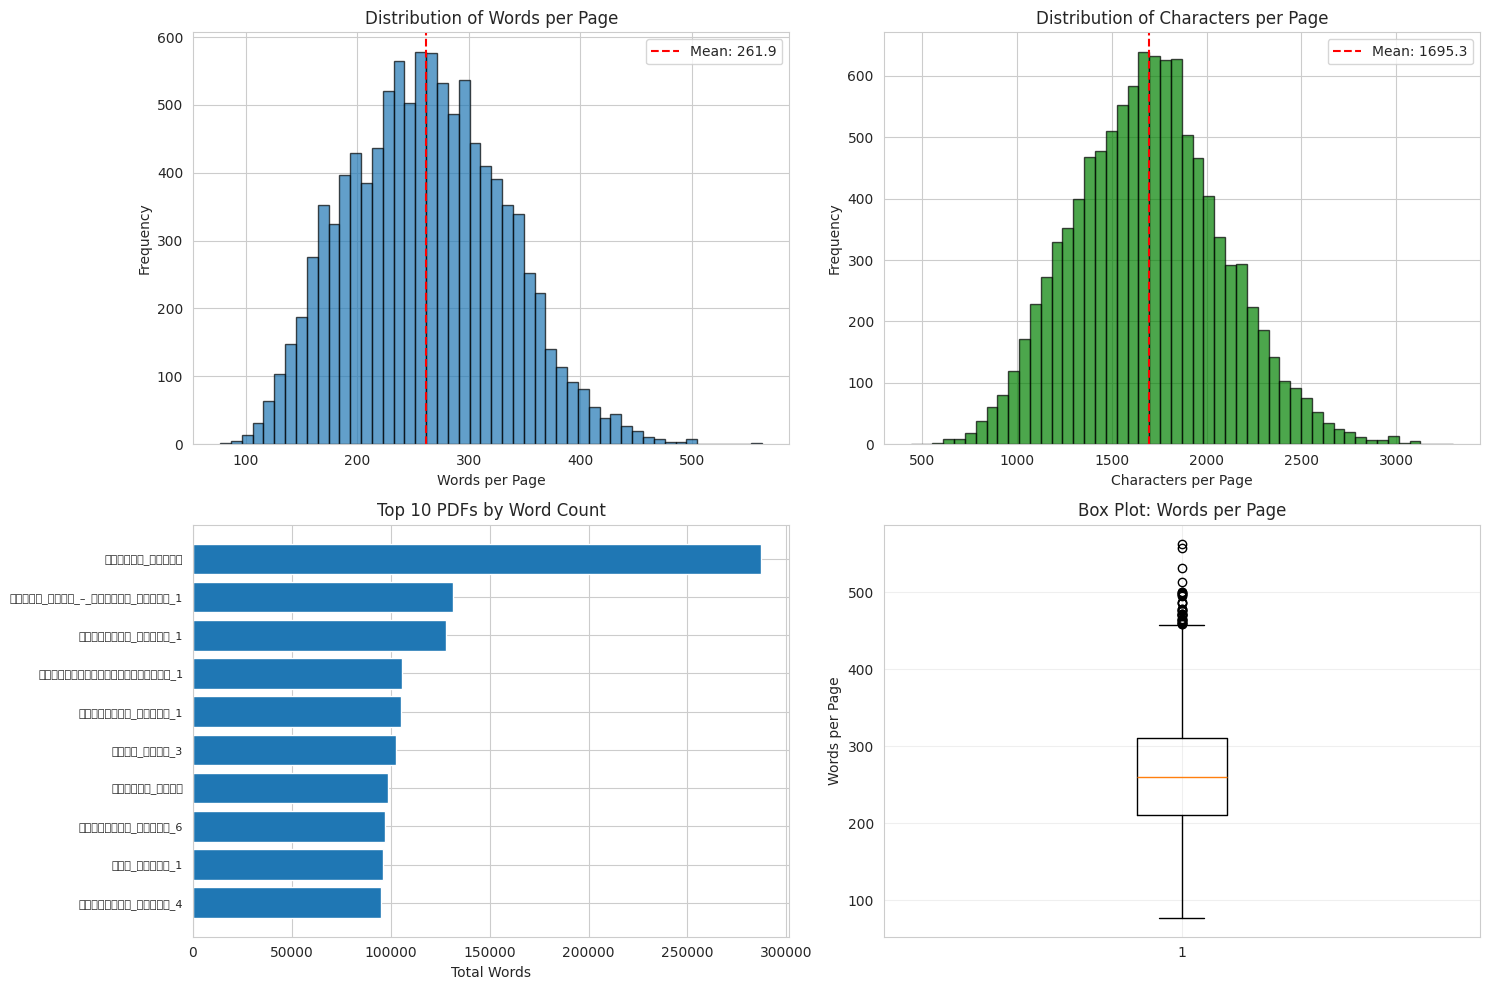

In [10]:
# Visualize raw corpus statistics
plot_distributions(raw_stats, ANALYSIS_DIR / "raw_corpus_distribution.png")

## 7. Clean Corpus (Remove English and URLs)

In [11]:
def clean_corpus(corpus: Dict[str, List[str]]) -> Dict[str, List[str]]:
    """
    Apply cleaning to entire corpus.
    """
    cleaned_corpus = {}

    print("\nCleaning corpus (removing English and URLs)...")

    for pdf_name, page_texts in tqdm(corpus.items(), desc="Cleaning PDFs"):
        cleaned_pages = []

        for page_text in page_texts:
            cleaned_text = clean_text(page_text)

            # Only keep if there's substantial content left
            if len(cleaned_text.strip()) > 50:  # Minimum 50 characters
                cleaned_pages.append(cleaned_text)

        if cleaned_pages:
            cleaned_corpus[pdf_name] = cleaned_pages

    print(f"✓ Cleaning complete")
    print(f"   PDFs before: {len(corpus)}")
    print(f"   PDFs after: {len(cleaned_corpus)}")

    return cleaned_corpus


# Clean the corpus
cleaned_corpus = clean_corpus(raw_corpus)


Cleaning corpus (removing English and URLs)...


Cleaning PDFs:   0%|          | 0/34 [00:00<?, ?it/s]

✓ Cleaning complete
   PDFs before: 34
   PDFs after: 34


In [12]:
# Analyze cleaned corpus
cleaned_stats = analyze_corpus(cleaned_corpus, "Cleaned Corpus (After Removing English)")

# Save statistics
with open(ANALYSIS_DIR / "cleaned_corpus_stats.json", 'w', encoding='utf-8') as f:
    json.dump(cleaned_stats, f, indent=2, ensure_ascii=False)

print(f"\n✓ Cleaned statistics saved to: {ANALYSIS_DIR / 'cleaned_corpus_stats.json'}")


CLEANED CORPUS (AFTER REMOVING ENGLISH) ANALYSIS

📚 Corpus Overview:
   PDFs: 34
   Total Pages: 10,511
   Total Words: 2,655,157
   Total Characters: 17,081,737

📊 Words per Page:
   Mean: 252.6
   Median: 251.0
   Std Dev: 67.6
   Min: 28
   Max: 544
   25th percentile: 203.0
   75th percentile: 299.0

📊 Characters per Page:
   Mean: 1625.1
   Median: 1627.0
   Std Dev: 387.3
   Min: 185
   Max: 3228

✓ Cleaned statistics saved to: /content/drive/Othercomputers/My Mac/Multi-lingual-Buddhist-Conversational-Agent/data/preprocessed/analysis/cleaned_corpus_stats.json


## 8. Separate Sinhala and Pali

In [13]:
# Separate languages
# You can adjust sinhala_threshold (0.0 to 1.0) based on results
# Lower threshold = more text classified as Sinhala
# Higher threshold = more text classified as Pali

SINHALA_THRESHOLD = 0.95  # Default: 95% Sinhala characters to be considered Sinhala

sinhala_texts, pali_texts, separation_stats = separate_languages(
    cleaned_corpus,
    sinhala_threshold=SINHALA_THRESHOLD
)

# Save separation statistics
with open(ANALYSIS_DIR / "language_separation_stats.json", 'w', encoding='utf-8') as f:
    # Convert defaultdict to regular dict for JSON serialization
    stats_to_save = separation_stats.copy()
    stats_to_save['pdf_classifications'] = dict(stats_to_save['pdf_classifications'])
    json.dump(stats_to_save, f, indent=2, ensure_ascii=False)


Classifying pages by language...


Processing PDFs:   0%|          | 0/34 [00:00<?, ?it/s]


✓ Language separation complete
   Total pages: 10511
   Sinhala pages: 10511 (100.0%)
   Pali pages: 0 (0.0%)


In [14]:
# Show sample from each language
print("\n" + "="*70)
print("SAMPLE TEXTS")
print("="*70)

if sinhala_texts:
    print("\n📝 Sinhala Sample (first 300 characters):")
    print("-" * 70)
    print(sinhala_texts[0][:300])
    print("...")

if pali_texts:
    print("\n📝 Pali Sample (first 300 characters):")
    print("-" * 70)
    print(pali_texts[0][:300])
    print("...")


SAMPLE TEXTS

📝 Sinhala Sample (first 300 characters):
----------------------------------------------------------------------
නමෝ තස්ස භගවතෝ සබ්බධම්මේසු අප්පටිහතඤාණචාරස්ස දසබලධරස්ස චතුවේසාරජ්ජවිසාරදස්ස සබ්බසත්තුත්තමස්ස ධම්මිස්සරස්ස ධම්මරාජස්ස ධම්මස්සාමිස්ස තථාගතස්ස සබ්බඤ්ඤුනො සම්මාසම්බුද්ධස්ස භාග්‍යවත් වූ සියලු ධර්මයන්හි නොපැකිල ඥානචාර සහිත වූ දසබලධාරී වූ චතුවෛශාරදත්ව විශාරද වූ සියලු සත්වයන්ට උත්තම වූ ධර්මයට ඊශ්වර වූ ධර්මර
...


## 9. Save Final Corpora

In [15]:
# Save Sinhala corpus
print("\nSaving final corpora...")

with open(SINHALA_CORPUS_FILE, 'w', encoding='utf-8') as f:
    f.write("\n\n".join(sinhala_texts))

print(f"✓ Sinhala corpus saved: {SINHALA_CORPUS_FILE}")
print(f"   Size: {SINHALA_CORPUS_FILE.stat().st_size / (1024*1024):.2f} MB")

# Save Pali corpus
with open(PALI_CORPUS_FILE, 'w', encoding='utf-8') as f:
    f.write("\n\n".join(pali_texts))

print(f"✓ Pali corpus saved: {PALI_CORPUS_FILE}")
print(f"   Size: {PALI_CORPUS_FILE.stat().st_size / (1024*1024):.2f} MB")


Saving final corpora...
✓ Sinhala corpus saved: /content/drive/Othercomputers/My Mac/Multi-lingual-Buddhist-Conversational-Agent/data/preprocessed/sinhala_text_corpus.txt
   Size: 42.27 MB
✓ Pali corpus saved: /content/drive/Othercomputers/My Mac/Multi-lingual-Buddhist-Conversational-Agent/data/preprocessed/pali_text_corpus.txt
   Size: 0.00 MB


## 10. Post-processing Analysis

In [16]:
def analyze_text_list(texts: List[str], corpus_name: str) -> Dict:
    """
    Analyze a list of texts.
    """
    total_words = 0
    total_chars = 0

    for text in texts:
        total_chars += len(text)
        total_words += len(text.split())

    return {
        'corpus_name': corpus_name,
        'num_texts': len(texts),
        'total_words': total_words,
        'total_characters': total_chars
    }


# Analyze separated corpora
sinhala_final_stats = analyze_text_list(sinhala_texts, "Sinhala")
pali_final_stats = analyze_text_list(pali_texts, "Pali")

print("\n" + "="*70)
print("FINAL CORPUS STATISTICS")
print("="*70)

print(f"\n📚 Sinhala Corpus:")
print(f"   Pages: {sinhala_final_stats['num_texts']:,}")
print(f"   Words: {sinhala_final_stats['total_words']:,}")
print(f"   Characters: {sinhala_final_stats['total_characters']:,}")

print(f"\n📚 Pali Corpus:")
print(f"   Pages: {pali_final_stats['num_texts']:,}")
print(f"   Words: {pali_final_stats['total_words']:,}")
print(f"   Characters: {pali_final_stats['total_characters']:,}")

# Save final statistics
final_stats = {
    'sinhala': sinhala_final_stats,
    'pali': pali_final_stats,
    'total': {
        'num_texts': sinhala_final_stats['num_texts'] + pali_final_stats['num_texts'],
        'total_words': sinhala_final_stats['total_words'] + pali_final_stats['total_words'],
        'total_characters': sinhala_final_stats['total_characters'] + pali_final_stats['total_characters']
    }
}

with open(ANALYSIS_DIR / "final_corpus_stats.json", 'w', encoding='utf-8') as f:
    json.dump(final_stats, f, indent=2, ensure_ascii=False)


FINAL CORPUS STATISTICS

📚 Sinhala Corpus:
   Pages: 10,511
   Words: 2,655,157
   Characters: 17,081,737

📚 Pali Corpus:
   Pages: 0
   Words: 0
   Characters: 0


## 11. Comprehensive Comparison Report

In [17]:
print("\n" + "="*70)
print("COMPREHENSIVE PREPROCESSING REPORT")
print("="*70)

# Before vs After comparison
print("\n📊 BEFORE PREPROCESSING (Raw Corpus):")
print(f"   Total Words: {raw_stats['total_words']:,}")
print(f"   Total Characters: {raw_stats['total_characters']:,}")
print(f"   Total Pages: {raw_stats['num_pages']:,}")

print("\n📊 AFTER CLEANING (English & URLs Removed):")
print(f"   Total Words: {cleaned_stats['total_words']:,}")
print(f"   Total Characters: {cleaned_stats['total_characters']:,}")
print(f"   Total Pages: {cleaned_stats['num_pages']:,}")

print("\n📊 AFTER LANGUAGE SEPARATION:")
print(f"   Sinhala Words: {sinhala_final_stats['total_words']:,}")
print(f"   Pali Words: {pali_final_stats['total_words']:,}")
print(f"   Total Words: {sinhala_final_stats['total_words'] + pali_final_stats['total_words']:,}")

# Calculate reductions
word_reduction = raw_stats['total_words'] - cleaned_stats['total_words']
word_reduction_pct = (word_reduction / raw_stats['total_words']) * 100

print("\n📉 DATA REDUCTION:")
print(f"   Words removed (cleaning): {word_reduction:,} ({word_reduction_pct:.1f}%)")
print(f"   Pages removed (cleaning): {raw_stats['num_pages'] - cleaned_stats['num_pages']:,}")

# Language distribution
total_final_words = sinhala_final_stats['total_words'] + pali_final_stats['total_words']
sinhala_pct = (sinhala_final_stats['total_words'] / total_final_words) * 100
pali_pct = (pali_final_stats['total_words'] / total_final_words) * 100

print("\n📊 LANGUAGE DISTRIBUTION:")
print(f"   Sinhala: {sinhala_pct:.1f}% ({sinhala_final_stats['total_words']:,} words)")
print(f"   Pali: {pali_pct:.1f}% ({pali_final_stats['total_words']:,} words)")

print("\n" + "="*70)

# Create summary report
summary_report = f"""
BUDDHIST CORPUS PREPROCESSING SUMMARY
{'='*70}

RAW CORPUS (Before Preprocessing):
  - Total PDFs: {raw_stats['num_pdfs']}
  - Total Pages: {raw_stats['num_pages']:,}
  - Total Words: {raw_stats['total_words']:,}
  - Total Characters: {raw_stats['total_characters']:,}

AFTER CLEANING (English & URLs Removed):
  - Total Pages: {cleaned_stats['num_pages']:,}
  - Total Words: {cleaned_stats['total_words']:,}
  - Total Characters: {cleaned_stats['total_characters']:,}
  - Words Removed: {word_reduction:,} ({word_reduction_pct:.1f}%)

FINAL CORPORA (After Language Separation):

  Sinhala Corpus:
    - Pages: {sinhala_final_stats['num_texts']:,}
    - Words: {sinhala_final_stats['total_words']:,} ({sinhala_pct:.1f}%)
    - Characters: {sinhala_final_stats['total_characters']:,}
    - File: sinhala_text_corpus.txt

  Pali Corpus:
    - Pages: {pali_final_stats['num_texts']:,}
    - Words: {pali_final_stats['total_words']:,} ({pali_pct:.1f}%)
    - Characters: {pali_final_stats['total_characters']:,}
    - File: pali_text_corpus.txt

NOTES:
  - This corpus is suitable for perplexity evaluation with SinLlama
  - Buddhist doctrinal text may show higher perplexity than general text
  - Pali transliterations are separated for specialized analysis

{'='*70}
"""

# Save report
with open(ANALYSIS_DIR / "preprocessing_summary.txt", 'w', encoding='utf-8') as f:
    f.write(summary_report)

print(summary_report)
print(f"\n✓ Summary report saved to: {ANALYSIS_DIR / 'preprocessing_summary.txt'}")


COMPREHENSIVE PREPROCESSING REPORT

📊 BEFORE PREPROCESSING (Raw Corpus):
   Total Words: 2,753,232
   Total Characters: 17,819,309
   Total Pages: 10,511

📊 AFTER CLEANING (English & URLs Removed):
   Total Words: 2,655,157
   Total Characters: 17,081,737
   Total Pages: 10,511

📊 AFTER LANGUAGE SEPARATION:
   Sinhala Words: 2,655,157
   Pali Words: 0
   Total Words: 2,655,157

📉 DATA REDUCTION:
   Words removed (cleaning): 98,075 (3.6%)
   Pages removed (cleaning): 0

📊 LANGUAGE DISTRIBUTION:
   Sinhala: 100.0% (2,655,157 words)
   Pali: 0.0% (0 words)


BUDDHIST CORPUS PREPROCESSING SUMMARY

RAW CORPUS (Before Preprocessing):
  - Total PDFs: 34
  - Total Pages: 10,511
  - Total Words: 2,753,232
  - Total Characters: 17,819,309

AFTER CLEANING (English & URLs Removed):
  - Total Pages: 10,511
  - Total Words: 2,655,157
  - Total Characters: 17,081,737
  - Words Removed: 98,075 (3.6%)

FINAL CORPORA (After Language Separation):
  
  Sinhala Corpus:
    - Pages: 10,511
    - Words: 2,6

## 12. Create Comparison Visualizations


✓ Comparison visualization saved to: /content/drive/Othercomputers/My Mac/Multi-lingual-Buddhist-Conversational-Agent/data/preprocessed/analysis/preprocessing_comparison.png


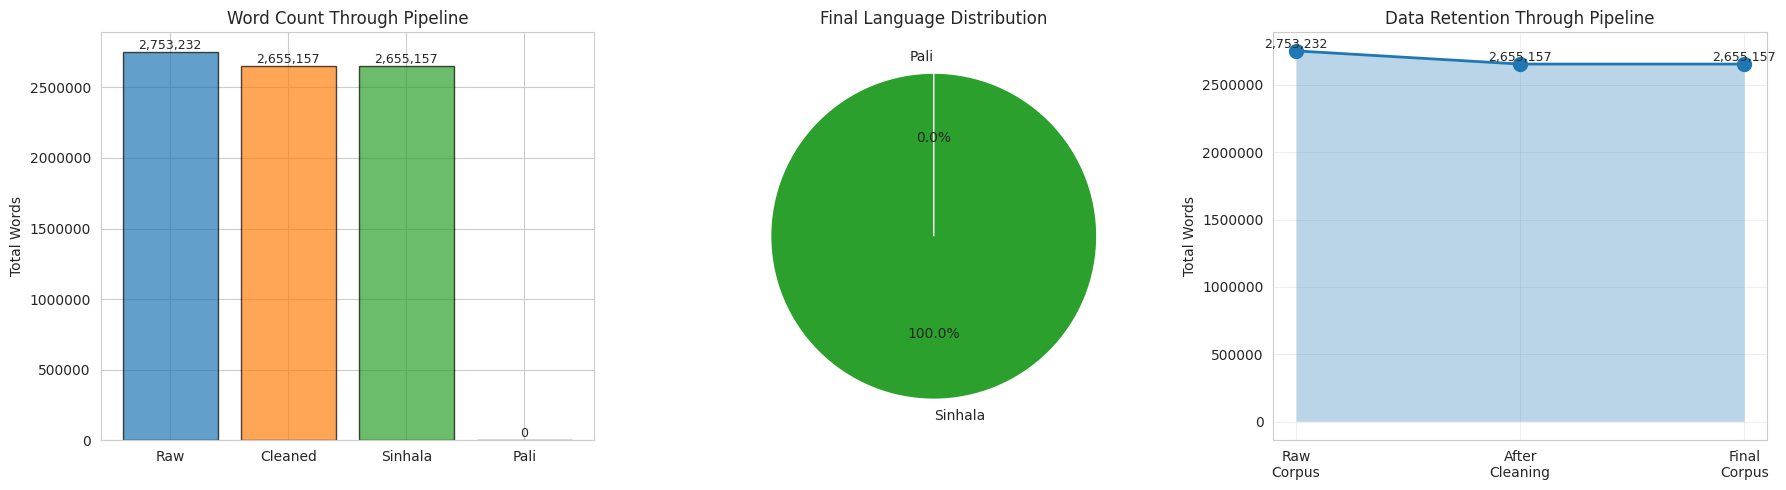

In [18]:
# Create before/after comparison visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Word count comparison
stages = ['Raw', 'Cleaned', 'Sinhala', 'Pali']
word_counts = [
    raw_stats['total_words'],
    cleaned_stats['total_words'],
    sinhala_final_stats['total_words'],
    pali_final_stats['total_words']
]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

axes[0].bar(stages, word_counts, color=colors, alpha=0.7, edgecolor='black')
axes[0].set_ylabel('Total Words')
axes[0].set_title('Word Count Through Pipeline')
axes[0].ticklabel_format(style='plain', axis='y')
for i, (stage, count) in enumerate(zip(stages, word_counts)):
    axes[0].text(i, count, f"{count:,}", ha='center', va='bottom', fontsize=9)

# Language distribution pie chart
axes[1].pie(
    [sinhala_final_stats['total_words'], pali_final_stats['total_words']],
    labels=['Sinhala', 'Pali'],
    autopct='%1.1f%%',
    colors=['#2ca02c', '#d62728'],
    startangle=90
)
axes[1].set_title('Final Language Distribution')

# Data reduction flow
reduction_stages = ['Raw\nCorpus', 'After\nCleaning', 'Final\nCorpus']
reduction_values = [
    raw_stats['total_words'],
    cleaned_stats['total_words'],
    sinhala_final_stats['total_words'] + pali_final_stats['total_words']
]

axes[2].plot(reduction_stages, reduction_values, marker='o', linewidth=2, markersize=10, color='#1f77b4')
axes[2].fill_between(range(len(reduction_stages)), reduction_values, alpha=0.3)
axes[2].set_ylabel('Total Words')
axes[2].set_title('Data Retention Through Pipeline')
axes[2].grid(True, alpha=0.3)
axes[2].ticklabel_format(style='plain', axis='y')
for i, val in enumerate(reduction_values):
    axes[2].text(i, val, f"{val:,}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "preprocessing_comparison.png", dpi=300, bbox_inches='tight')
print(f"\n✓ Comparison visualization saved to: {ANALYSIS_DIR / 'preprocessing_comparison.png'}")
plt.show()

## Summary

**This notebook completed:**

1. ✅ **Pre-processing Analysis**
   - Word counts, character counts
   - Statistical distributions (mean, median, std, min, max)
   - Per-PDF and per-page analysis

2. ✅ **Data Cleaning**
   - Removed English words
   - Removed URLs
   - Normalized whitespace

3. ✅ **Language Separation**
   - Separated Sinhala from Pali transliterations
   - Character-level and word-level analysis
   - Per-PDF language distribution

4. ✅ **Post-processing Analysis**
   - Before/after comparison
   - Language distribution statistics
   - Data reduction metrics

5. ✅ **Final Outputs**
   - `sinhala_text_corpus.txt` - Ready for SinLlama perplexity evaluation
   - `pali_text_corpus.txt` - Separated Pali transliterations
   - Comprehensive statistics and visualizations

**Next Steps:**
- Use `sinhala_text_corpus.txt` for perplexity evaluation with SinLlama
- Expect higher perplexity due to specialized Buddhist doctrinal vocabulary
- Consider fine-tuning SinLlama on this corpus for domain adaptation